In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data= pd.read_csv("C:/Users/devin/Coding/Customer PRoject/data/data.csv", encoding='latin-1')



In [2]:
data.info

<bound method DataFrame.info of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  Custome

In [3]:
data.isnull().any()

InvoiceNo      False
StockCode      False
Description     True
Quantity       False
InvoiceDate    False
UnitPrice      False
CustomerID      True
Country        False
dtype: bool

In [4]:
data.shape

(541909, 8)

Next I will Evaluate the null data

In [5]:
null_data = data[data.isnull().any(axis=1)]

In [6]:
null_data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,12/9/2011 10:26,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,12/9/2011 10:26,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,12/9/2011 10:26,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,12/9/2011 10:26,10.79,NaN,United Kingdom


Getting counts of null data in Description and CustomerID cols


In [7]:
null_counts = null_data.isnull().sum()
print(null_counts)


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


removing null rows

In [8]:
data_clean = data.dropna(subset= ["CustomerID"])


Next analyze and change data types

In [9]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


In [10]:
data_clean = (
    data_clean.astype({
        'InvoiceNo': 'string',
        'CustomerID': 'string',
        'Description': 'string',
        'StockCode': 'string',
        'Country': 'category'
    })
)
data_clean['InvoiceDate'] = pd.to_datetime(data_clean['InvoiceDate'],
errors='coerce')

data_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  string        
 1   StockCode    406829 non-null  string        
 2   Description  406829 non-null  string        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  string        
 7   Country      406829 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(1), int64(1), string(4)
memory usage: 25.2 MB


Checking for nulls again

In [11]:
data_clean.isnull().any()

InvoiceNo      False
StockCode      False
Description    False
Quantity       False
InvoiceDate    False
UnitPrice      False
CustomerID     False
Country        False
dtype: bool

Analyzing customers

In [12]:
unique_customers = data_clean['CustomerID'].nunique()
print(f"Number of unique customers: {unique_customers}")

Number of unique customers: 4372


In [13]:
orders_per_customer = (
    data_clean.groupby('CustomerID')['InvoiceNo']
    .nunique()
    .reset_index(name='OrderCount')
)

Previous step groups orders by customer id. Then creates a dataframe to house the orders per customer info

In [14]:
orders_per_customer.head()

,CustomerID,OrderCount
0,12346.0,2
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


Determine which customers are repeat or not

In [15]:
orders_per_customer['CustomerType']= np.where(orders_per_customer['OrderCount']>1, 'Repeat', 'One-Time')
orders_per_customer.head()

,CustomerID,OrderCount,CustomerType
0,12346.0,2,Repeat
1,12347.0,7,Repeat
2,12348.0,4,Repeat
3,12349.0,1,One-Time
4,12350.0,1,One-Time


Getting more info on CT

CustomerType
Repeat      69.967978
One-Time    30.032022
Name: proportion, dtype: float64

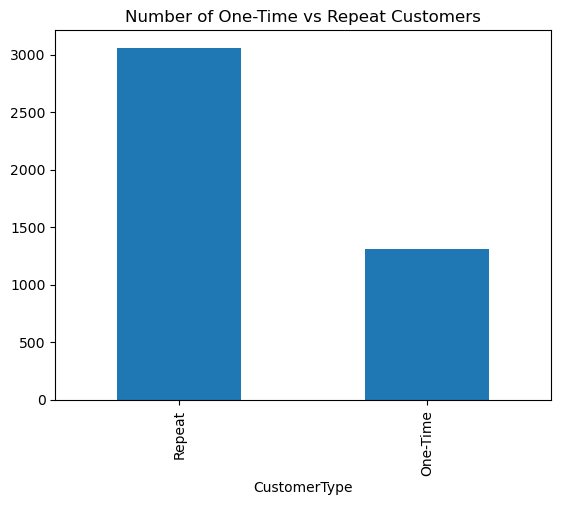

In [16]:
orders_per_customer['CustomerType'].value_counts().plot(kind='bar')
plt.title('Number of One-Time vs Repeat Customers')
orders_per_customer['CustomerType'].value_counts(normalize=True) * 100

7 in 10 customers come back

So we've made a dataframe that houses the repeat and one time customer columns. Now i need to make a revenue column

In [17]:
data_with_revenue = data_clean.copy()
data_with_revenue = data_with_revenue[(data_with_revenue['Quantity'] > 0) & (data_with_revenue['UnitPrice'] > 0)]
data_with_revenue['Revenue'] = data_with_revenue['Quantity'] * data_with_revenue['UnitPrice']

data_with_revenue[['Quantity', 'UnitPrice', 'Revenue']].describe()

,Quantity,UnitPrice,Revenue
count,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,22.397000
std,179.331775,22.097877,309.071041
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.680000
50%,6.000000,1.950000,11.800000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


Next we'll merge the data_with_revenue df with the orders_per_customer df. Then we'll check for na's after the merge to see if it worked

In [18]:
data_with_revenue = data_with_revenue.merge(orders_per_customer[['CustomerID', 'CustomerType']], on='CustomerID', how='left')
data_with_revenue['CustomerType'].value_counts(dropna=False)
data_with_revenue[data_with_revenue['CustomerType'].isna()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,CustomerType


This next step just congregates all the revenue of the two customer types

In [19]:
rev_by_type = (
    data_with_revenue.groupby('CustomerType', dropna=False)['Revenue']
    .sum()
    .sort_values(ascending=False)
)

rev_by_type

CustomerType
Repeat      8467285.493
One-Time     444122.411
Name: Revenue, dtype: float64

What percent of our revenue comes from which customer type

In [20]:
rev_split = (rev_by_type / rev_by_type.sum()).mul(100).round(2)
rev_split

CustomerType
Repeat      95.02
One-Time     4.98
Name: Revenue, dtype: float64

Overall Top Products

Groups by stock code to see which product generates the most revenue

In [21]:
product_rev = (
    data_with_revenue
.groupby(['StockCode', 'Description'])['Revenue']
.sum()
.sort_values(ascending=False)
.reset_index()
)

product_rev.head(20)

,StockCode,Description,Revenue
0,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,22423,REGENCY CAKESTAND 3 TIER,142592.95
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,100448.15
3,85099B,JUMBO BAG RED RETROSPOT,85220.78
4,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
5,POST,POSTAGE,77803.96
6,47566,PARTY BUNTING,68844.33
7,84879,ASSORTED COLOUR BIRD ORNAMENT,56580.34
8,M,Manual,53779.93
9,23084,RABBIT NIGHT LIGHT,51346.20


Top Products within each customer type

In [22]:
product_rev_by_customer = (
    data_with_revenue
.groupby(['CustomerType', 'StockCode', 'Description'])['Revenue']
.sum()
.sort_values(ascending=False)
.reset_index()
)

product_rev_by_customer.head(20)

,CustomerType,StockCode,Description,Revenue
0,Repeat,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,Repeat,22423,REGENCY CAKESTAND 3 TIER,136888.30
2,Repeat,85123A,WHITE HANGING HEART T-LIGHT HOLDER,96848.40
3,Repeat,85099B,JUMBO BAG RED RETROSPOT,82307.02
4,Repeat,23166,MEDIUM CERAMIC TOP STORAGE JAR,81099.39
5,Repeat,POST,POSTAGE,73009.96
6,Repeat,47566,PARTY BUNTING,65834.48
7,Repeat,84879,ASSORTED COLOUR BIRD ORNAMENT,54491.03
8,Repeat,M,Manual,51659.32
9,Repeat,23084,RABBIT NIGHT LIGHT,50776.36


Now top 10 products by customer type

In [23]:
top10_products_by_type = (product_rev_by_customer
.sort_values(['CustomerType', 'Revenue'], ascending=[True, False])
.groupby('CustomerType', as_index=False)
.head(10)
)
top10_products_by_type

,CustomerType,StockCode,Description,Revenue
370,One-Time,22423,REGENCY CAKESTAND 3 TIER,5704.65
443,One-Time,POST,POSTAGE,4794.00
528,One-Time,22413,METAL SIGN TAKE IT OR LEAVE IT,4049.80
574,One-Time,85123A,WHITE HANGING HEART T-LIGHT HOLDER,3599.75
653,One-Time,22197,SMALL POPCORN HOLDER,3215.00
686,One-Time,47566,PARTY BUNTING,3009.85
703,One-Time,85099B,JUMBO BAG RED RETROSPOT,2913.76
871,One-Time,21915,RED HARMONICA IN BOX,2157.75
875,One-Time,M,Manual,2120.61
886,One-Time,22086,PAPER CHAIN KIT 50'S CHRISTMAS,2091.65


So this is pretty cool, Here i created a table that shows the total revenue of each product by customer type.

In [24]:
product_pivot = (
    product_rev_by_customer.pivot_table(
        index=['StockCode', 'Description'],
        columns='CustomerType',
        values='Revenue',
        aggfunc='sum',
        fill_value=0
    )
)

product_pivot.head(10)

,CustomerType,One-Time,Repeat
StockCode,Description,,
10002,INFLATABLE POLITICAL GLOBE,7.65,691.90
10080,GROOVY CACTUS INFLATABLE,0.00,114.41
10120,DOGGY RUBBER,4.41,36.12
10123C,HEARTS WRAPPING TAPE,0.65,2.60
10124A,SPOTS ON RED BOOKCOVER TAPE,1.26,5.46
10124G,ARMY CAMO BOOKCOVER TAPE,0.00,7.14
10125,MINI FUNKY DESIGN TAPES,20.40,909.90
10133,COLOURING PENCILS BROWN TUBE,74.98,1068.63
10135,COLOURING PENCILS BROWN TUBE,93.40,1693.29


This part just shows the percentage of revenue each customer type generates per product

In [25]:
if "Repeat" in product_pivot.columns:
    product_pivot["RepeatSharePct"] = (
        product_pivot["Repeat"] / product_pivot.sum(axis=1)
    ).mul(100).round(2)

product_pivot.sort_values("RepeatSharePct")

,CustomerType,One-Time,Repeat,RepeatSharePct
StockCode,Description,,,
17001,HEAVENS SCENT FRAGRANCE OILS ASSTD,20.88,0.00,0.0
90190B,GOLD/AMBER DROP EARRINGS W LEAF,17.70,0.00,0.0
90054,CRACKED GLAZE EARRINGS RED,2.55,0.00,0.0
35610C,WHITE CHRISTMAS FLOCK DROPLET,30.00,0.00,0.0
90214O,"LETTER ""O"" BLING KEY RING",3.48,0.00,0.0
...,...,...,...,...
23567,EGG CUP HENRIETTA HEN PINK,0.00,233.75,100.0
21196,ROUND WHITE CONFETTI IN TUBE,0.00,146.85,100.0
23562,SET OF 6 RIBBONS PERFECTLY PRETTY,0.00,684.05,100.0


Phase 2: AOV, Revenue per customer, purchase timing

In [26]:
data_with_revenue.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,CustomerType
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,Repeat
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Repeat
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,Repeat
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Repeat
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Repeat


This next step creates an OrderRevenue df that shows the totat order revenue per invoice 

In [27]:
order_revenue = (data_with_revenue
.groupby('InvoiceNo', as_index=False)
.agg(
    OrderRevenue=('Revenue', 'sum'),
)
)
order_revenue.head()

,InvoiceNo,OrderRevenue
0,536365,139.12
1,536366,22.20
2,536367,278.73
3,536368,70.05
4,536369,17.85


This next step calculates AOV aka Average Order Value. Also teaches me how to output something as a dollar amount on the fly

In [28]:
aov = order_revenue['OrderRevenue'].mean().round(2)
aov_currency = f"${aov:,.2f}"
aov_currency

'$480.87'

In [29]:
order_revenue["OrderRevenue"].describe().round(2)

count     18532.00
mean        480.87
std        1678.20
min           0.38
25%         158.04
50%         303.04
75%         471.84
max      168469.60
Name: OrderRevenue, dtype: float64

This next step merges the 

In [30]:
order_with_customer = order_revenue.merge(
    data_with_revenue[['InvoiceNo', 'CustomerID']],
    on='InvoiceNo',
    how='left'
).merge(
    orders_per_customer[['CustomerID', 'CustomerType']],
    on='CustomerID',
    how='left'
)
order_with_customer.head()

,InvoiceNo,OrderRevenue,CustomerID,CustomerType
0,536365,139.12,17850.0,Repeat
1,536365,139.12,17850.0,Repeat
2,536365,139.12,17850.0,Repeat
3,536365,139.12,17850.0,Repeat
4,536365,139.12,17850.0,Repeat


In [31]:
aov_by_type = (order_with_customer
    .groupby('CustomerType')
    .agg(AOV=('OrderRevenue', 'mean'))
    .reset_index()
)
aov_by_type.round(2)


,CustomerType,AOV
0,One-Time,516.95
1,Repeat,763.77


Revenue per customer (LTV Proxy)

In [32]:
revenue_per_customer = (
    data_with_revenue
    .groupby('CustomerID', as_index=False)
    .agg(
        TotalRevenue=('Revenue', 'sum'),
        OrderCount=('InvoiceNo', 'nunique'),
    )
)

In [33]:
revenue_per_customer["TotalRevenue"].describe().round(2)

count      4338.00
mean       2054.27
std        8989.23
min           3.75
25%         307.41
50%         674.48
75%        1661.74
max      280206.02
Name: TotalRevenue, dtype: float64

In [34]:
revenue_per_customer['AvgRevenuePerOrder'] = (
    revenue_per_customer['TotalRevenue']/revenue_per_customer['OrderCount']
).round(2)
revenue_per_customer.head()

,CustomerID,TotalRevenue,OrderCount,AvgRevenuePerOrder
0,12346.0,77183.60,1,77183.60
1,12347.0,4310.00,7,615.71
2,12348.0,1797.24,4,449.31
3,12349.0,1757.55,1,1757.55
4,12350.0,334.40,1,334.40


In [35]:
revenue_per_customer = revenue_per_customer.merge(
    orders_per_customer[['CustomerID', 'CustomerType']],
    on='CustomerID',
    how='left'
)
revenue_per_customer.head()

,CustomerID,TotalRevenue,OrderCount,AvgRevenuePerOrder,CustomerType
0,12346.0,77183.60,1,77183.60,Repeat
1,12347.0,4310.00,7,615.71,Repeat
2,12348.0,1797.24,4,449.31,Repeat
3,12349.0,1757.55,1,1757.55,One-Time
4,12350.0,334.40,1,334.40,One-Time


In [36]:
revenue_per_customer.groupby('CustomerType')['TotalRevenue'].mean().round(2)

CustomerType
One-Time     346.43
Repeat      2770.71
Name: TotalRevenue, dtype: float64

First and last purchase dates per customer

In [37]:
purchase_timing = (
    data_with_revenue
    .groupby('CustomerID', as_index=False)
    .agg(
        FirstPurchase=('InvoiceDate', 'min'),
        LastPurchase=('InvoiceDate', 'max'),
        OrderCount=('InvoiceNo', 'nunique')
    )
)
purchase_timing.head()

,CustomerID,FirstPurchase,LastPurchase,OrderCount
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,1
1,12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00,7
2,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,4
3,12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,1
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1


Customer lifespan

In [38]:
purchase_timing['CustomerLifespanDays'] = (
    purchase_timing['LastPurchase'] - 
    purchase_timing['FirstPurchase']
).dt.days
purchase_timing.head()

,CustomerID,FirstPurchase,LastPurchase,OrderCount,CustomerLifespanDays
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,1,0
1,12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00,7,365
2,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,4,282
3,12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,1,0
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,0


Average time between purchases 

In [39]:
purchase_timing['AvgDaysBetweenOrders'] = (
    purchase_timing['CustomerLifespanDays'] / 
    (purchase_timing['OrderCount'] - 1)
)

purchase_timing.loc[
    purchase_timing['OrderCount'] == 1, 'AvgDaysBetweenOrders'
] = None

All together now

In [40]:
purchase_timing = purchase_timing.merge(
    revenue_per_customer[["CustomerID", "TotalRevenue"]],
    on="CustomerID",
    how="left"
)
purchase_timing.head()

,CustomerID,FirstPurchase,LastPurchase,OrderCount,CustomerLifespanDays,AvgDaysBetweenOrders,TotalRevenue
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,1,0,NaN,77183.60
1,12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00,7,365,60.833333,4310.00
2,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,4,282,94.000000,1797.24
3,12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,1,0,NaN,1757.55
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,0,NaN,334.40



Phase 3 Cohort Analysis. Grouping customers based on when they first purchased. Basically trying to see who came back. Who is continuing to bbuy

Identifying each customers cohort

In [41]:
customer_cohorts = (
    data_with_revenue
    .groupby('CustomerID', as_index=False)
    .agg(CohortDate=('InvoiceDate', 'min'))
)

Normalizing to month

In [42]:
customer_cohorts['CohortMonth'] = (customer_cohorts['CohortDate'].dt.to_period('M')
                                    .dt.to_timestamp()
                                )

Merging with transactions

In [43]:
data_with_cohort = data_with_revenue.merge(
    customer_cohorts[['CustomerID', 'CohortMonth']],
    on='CustomerID',
    how='left'
)

Caculating cohort age

In [44]:
data_with_cohort['InvoiceMonth'] = (data_with_cohort['InvoiceDate'].dt.to_period('M')
                                    .dt.to_timestamp())

data_with_cohort['CohortIndex'] = (
    (data_with_cohort['InvoiceMonth'] - data_with_cohort['CohortMonth'])
    .dt.days // 30
)

Cohort Matrix aka Retention Counts.

Essentially in month X, how many customers from this cohort were active?

In [45]:
cohort_counts = (
    data_with_cohort
    .groupby(['CohortMonth', 'CohortIndex'])
    .agg(
        ActiveCustomers=('CustomerID', 'nunique')
    )
    .reset_index()
)

Retention Table

In [46]:
cohort_pivot = cohort_counts.pivot_table(
    index='CohortMonth',
    columns='CohortIndex',
    values='ActiveCustomers'
)

cohort_size = cohort_pivot.iloc[:,0]

retention = cohort_pivot.divide(cohort_size, axis=0).round(2)

In [47]:
cohort_pivot

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12-01,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01-01,417.0,158.0,NaN,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02-01,380.0,71.0,108.0,NaN,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03-01,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04-01,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05-01,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06-01,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Example: by december 2010 324 customers had gone a month since their last purchase

Interpreting my tablesd. 

Essential question: After customers first show up, do they come back?

on average about 20-40% come back after their first purchase


In [50]:
retention_vis = retention.iloc[:, :4]


retention_vis.reset_index().to_csv("C:/Users/devin/Coding/Customer PRoject/data/retention.csv", index=False)

retention_vis

CohortIndex,0,1,2,3
CohortMonth,,,,
2010-12-01,1.0,0.37,0.32,0.38
2011-01-01,1.0,0.38,NaN,0.23
2011-02-01,1.0,0.19,0.28,NaN
2011-03-01,1.0,0.15,0.25,0.20
2011-04-01,1.0,0.21,0.20,0.21
2011-05-01,1.0,0.19,0.17,0.17
2011-06-01,1.0,0.17,0.16,0.26
2011-07-01,1.0,0.18,0.21,0.22
2011-08-01,1.0,0.21,0.25,0.24


Creating anm average revenue per custosomer table by cohort 

In [58]:
avg_revenue_per_cohort = revenue_per_customer.merge(
    customer_cohorts[['CustomerID', 'CohortMonth']], on='CustomerID', how='left')

avg_revenue_per_cohort = avg_revenue_per_cohort.groupby(
    ['CohortMonth'], as_index=False
    ).agg(AvgRevenuePerCustomer=('TotalRevenue', 'mean')).round(2)

avg_revenue_per_cohort

,CohortMonth,AvgRevenuePerCustomer
0,2010-12-01,5098.47
1,2011-01-01,2699.96
2,2011-02-01,1562.83
3,2011-03-01,1424.25
4,2011-04-01,1088.74
5,2011-05-01,1604.03
6,2011-06-01,1129.98
7,2011-07-01,768.45
8,2011-08-01,1160.05
9,2011-09-01,780.26


In [59]:
avg_revenue_per_cohort.reset_index().to_csv("C:/Users/devin/Coding/Customer PRoject/data/avg_revenue_per_cohort.csv", index=False)